<a href="https://colab.research.google.com/github/akshara-git17/synent-task8-customer-segmentation-akshara_dave/blob/main/Task8_Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Segmentation using K-Means Clustering

## Synent Technologies Data Science Internship

### Submitted By:
Akshara Dave

### Objective

The objective of this project is to segment customers into distinct groups based on their income and spending behavior using K-Means Clustering. Customer segmentation helps businesses understand customer patterns and develop targeted marketing strategies.

# Business Objective

Businesses often have customers with different purchasing behaviors. Treating all customers the same can reduce the effectiveness of marketing efforts.

The goal of this project is to:

- Identify distinct customer groups.
- Understand customer spending behavior.
- Support targeted marketing strategies.
- Improve customer relationship management.
- Assist business decision-making using machine learning techniques.

In [2]:
#importing libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)

In [3]:
#load dataset
df = pd.read_csv('Mall_Customers.csv')

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# Dataset Overview

Before building the clustering model, it is important to understand the dataset structure, data types, and available features.

In [4]:
df.shape

(200, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [7]:
#checking for missing values
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [8]:
#checking for duplicates
df.duplicated().sum()

np.int64(0)

# Column Description

The dataset contains customer demographic and spending information that can be used to identify distinct customer groups for targeted marketing and business decision-making.

| Column Name | Description | Business Importance |
|------------|-------------|--------------------|
| CustomerID | Unique identifier assigned to each customer. | Used to uniquely distinguish customers. Not useful for clustering because it does not represent customer behavior. |
| Gender | Gender of the customer (Male/Female). | Helps understand customer demographics and compare spending patterns across genders. |
| Age | Age of the customer in years. | Useful for identifying customer segments based on age groups and purchasing behavior. |
| Annual Income (k$) | Customer's annual income measured in thousands of dollars. | Indicates purchasing power and financial capacity of customers. |
| Spending Score (1-100) | Score assigned by the mall based on spending behavior and purchase frequency. | Represents customer engagement and spending habits. Higher scores indicate more active and valuable customers. |

## Features Selected for Clustering

Customer segmentation aims to group customers based on similar purchasing behavior. For this purpose, the following features are selected:

- **Annual Income (k$)**
- **Spending Score (1-100)**

These features are chosen because they directly represent a customer's financial capability and spending behavior, making them ideal for identifying meaningful customer segments.

## Expected Customer Segments

Using clustering techniques, customers may be grouped into categories such as:

1. High Income – High Spending
2. High Income – Low Spending
3. Low Income – High Spending
4. Low Income – Low Spending
5. Average Income – Average Spending

These segments can help businesses design targeted marketing campaigns, improve customer retention, and increase profitability.

# Data Cleaning

Before applying machine learning algorithms, the dataset is checked for missing values, duplicate records, and data consistency issues.

In [8]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


### Data Cleaning Summary

- No missing values were found in the dataset.
- No duplicate records were detected.
- Numerical columns contain valid values and require no additional cleaning.

The dataset is clean and ready for exploratory analysis and clustering.

# Analysis 1: Gender Distribution

### Objective

To understand the distribution of male and female customers in the dataset.

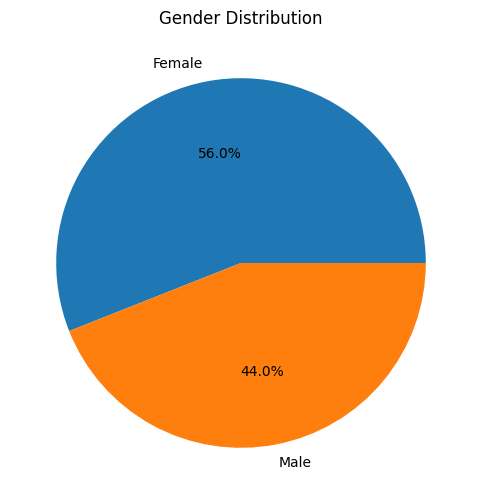

In [11]:
plt.figure(figsize=(6,6))

df['Gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Gender Distribution')

plt.ylabel('')

plt.show()

### Insight

This analysis shows the proportion of male and female customers in the dataset and helps understand the overall customer composition.Here we can see that the female customer composition is more compared to male customer composition.

# Analysis 2: Age Distribution

### Objective

To analyze the age distribution of customers.

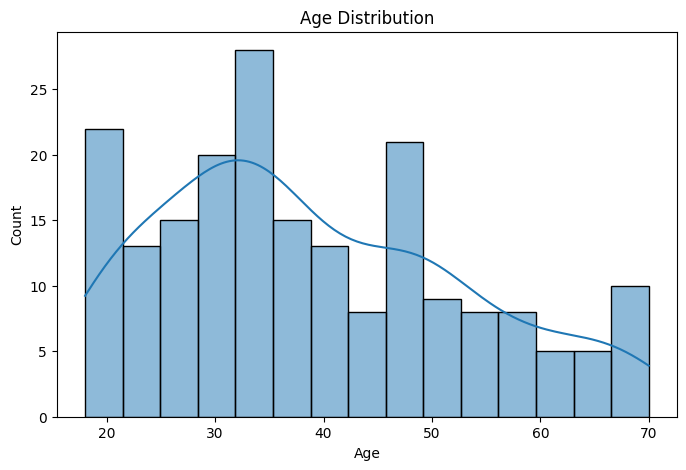

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Age'],
    bins=15,
    kde=True
)

plt.title('Age Distribution')

plt.show()

### Insight

The age distribution helps identify the dominant age groups among customers and provides insights into the target audience.

# Analysis 3: Annual Income Distribution

### Objective

To analyze the distribution of customer annual income and understand the purchasing power of customers in the dataset.

Income is one of the most important factors in customer segmentation because it indicates a customer's financial capacity and potential spending ability.

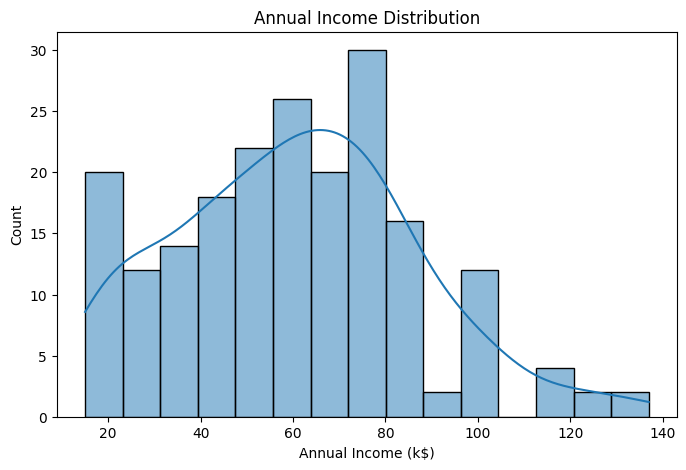

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Annual Income (k$)'],
    bins=15,
    kde=True
)

plt.title('Annual Income Distribution')

plt.show()

### Insight

The income distribution provides an overview of the financial diversity among customers. Understanding income patterns helps identify customer groups with different purchasing capacities and supports effective segmentation.

# Analysis 4: Spending Score Distribution

### Objective

To analyze customer spending behavior using the spending score assigned by the mall.

The spending score reflects how actively a customer shops and interacts with the business. Customers with higher scores are generally more engaged and valuable from a marketing perspective.

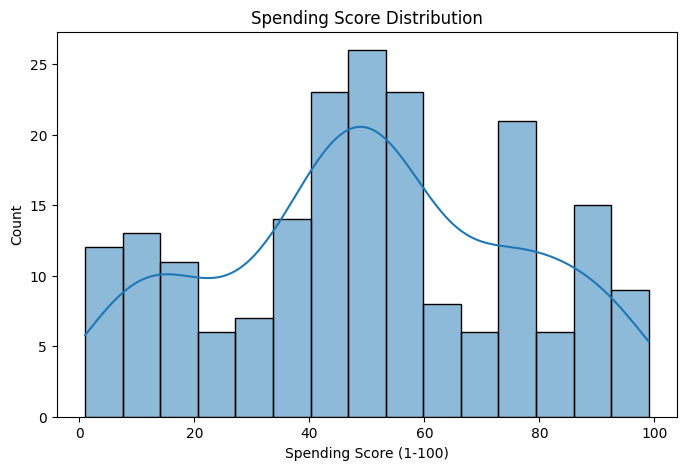

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Spending Score (1-100)'],
    bins=15,
    kde=True
)

plt.title('Spending Score Distribution')

plt.show()

### Insight

The spending score distribution helps identify variations in customer purchasing behavior. This information is valuable for distinguishing high-engagement customers from less active customers and forms a key component of customer segmentation.

# Analysis 5: Income vs Spending Score

### Objective

To visualize the relationship between customer income and spending behavior before applying clustering.

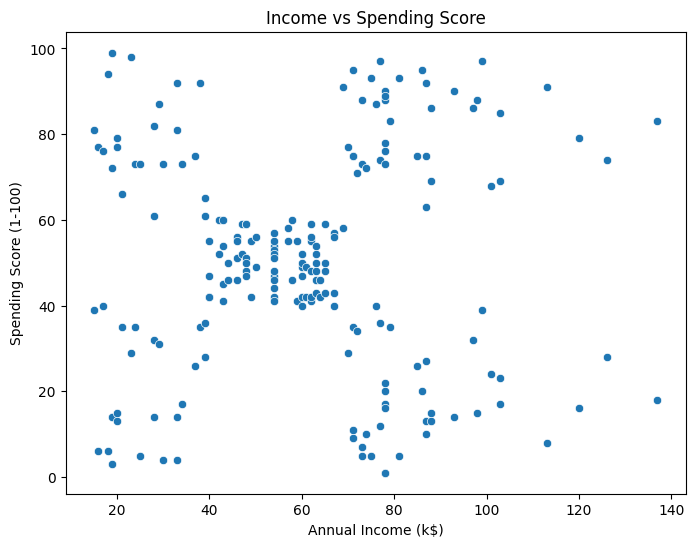

In [12]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)'
)

plt.title('Income vs Spending Score')

plt.show()

### Insight

The scatter plot suggests the presence of multiple customer groups with different spending behaviors, making the dataset suitable for clustering analysis.